# COVID-19 Data Catalog
Convert this dataset and metadata into interactive HTML

In [20]:
import snowflake.connector
import pandas as pd

from IPython.core.display import display, HTML
from pandas_profiling import ProfileReport
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# Read connection configuration
home = str(Path.home()) + '/Documents/'
with open(home + 'snowflake.cfg') as f:
    config = f.readlines()

# Remove line returns    
config = [x.strip() for x in config]

# Set to local variables
sf_account = config[0]
sf_user = config[1]
sf_pwd = config[2]

In [3]:
# Connect to Snowflake
# https://uja84855.us-east-1.snowflakecomputing.com/console#/internal/worksheet

sf_warehouse = 'COMPUTE_WH'

ctx = snowflake.connector.connect(
    account = sf_account,
    user = sf_user,
    password = sf_pwd,
    warehouse = sf_warehouse
    # role = 'SYSADMIN'
    )
cs = ctx.cursor()

# Optional config when connecting ...
    #database = 'CIMBA_PROD',
    #schema = 'MCP'
# or after connecting ...
    # cs.execute("USE ROLE SYSADMIN;")
    # cs.execute("USE DATABASE CIMBA_PROD;")
    # cs.execute("USE WAREHOUSE CIMBA_WH;")

In [4]:
# Test the connection
print(type(ctx))
print(type(cs))

<class 'snowflake.connector.connection.SnowflakeConnection'>
<class 'snowflake.connector.cursor.SnowflakeCursor'>


In [5]:
ctx.role

'SYSADMIN'

# Get List of Tables

In [6]:
# Get metadata from this dedicated metadata table
table_query = 'select * from "STARSCHEMA_COVID19"."PUBLIC"."METADATA";'
df = pd.read_sql(table_query, ctx)

In [7]:
df.shape

(317, 7)

In [8]:
df.head()

,TABLE,DESCRIPTION,COLUMN,TYPE,NULLABLE,COMMENTS,SOURCE
0,CT_US_COVID_TESTS,US COVID-19 testing and mortality,None,None,None,None,None
1,CT_US_COVID_TESTS,ISO-3166-1 entity name,COUNTRY_REGION,VARCHAR(16777216),False,United States only,CovidTracking API
2,CT_US_COVID_TESTS,ISO-3166-2 entity name (U.S. State),PROVINCE_STATE,VARCHAR(16777216),True,United States only,CovidTracking API
3,CT_US_COVID_TESTS,Date of data point,DATE,DATE,False,None,CovidTracking API
4,CT_US_COVID_TESTS,Positive cases on date of report,POSITIVE,"NUMBER(38,0)",False,None,CovidTracking API


In [9]:
lst_tablenames_meta = df['TABLE'].unique()
lst_tablenames_meta = sorted(lst_tablenames_meta)
print(len(lst_tablenames_meta))
lst_tablenames_meta

22


['CT_US_COVID_TESTS',
 'DEMOGRAPHICS',
 'HDX_ACAPS',
 'HS_BULK_DATA',
 'HUM_RESTRICTIONS_AIRLINE',
 'HUM_RESTRICTIONS_COUNTRY',
 'IHME_COVID_19',
 'JHU_COVID_19',
 'KFF_HCP_CAPACITY',
 'KFF_US_ICU_BEDS',
 'KFF_US_POLICY_ACTIONS',
 'KFF_US_STATE_MITIGATIONS',
 'METADATA',
 'NYT_US_COVID19',
 'PCM_DPS_COVID19',
 'PCM_DPS_COVID19_DETAILS',
 'RKI_GER_DETAILED_DASHBOARD',
 'SCS_BE_DETAILED_HOSPITALISATIONS',
 'SCS_BE_DETAILED_MORTALITY',
 'SCS_BE_DETAILED_PROVINCE_CASE_COUNTS',
 'SCS_BE_DETAILED_TESTS',
 'WHO_SITUATION_REPORTS']

In [10]:
# select TABLE_NAME from "STARSCHEMA_COVID19"."INFORMATION_SCHEMA"."TABLES" where TABLE_SCHEMA = 'PUBLIC';
table_query = 'select * from "STARSCHEMA_COVID19"."INFORMATION_SCHEMA"."TABLES" where TABLE_SCHEMA = \'PUBLIC\';'
df_infoschema = pd.read_sql(table_query, ctx)


In [11]:
df_infoschema

,TABLE_CATALOG,TABLE_SCHEMA,TABLE_NAME,TABLE_OWNER,TABLE_TYPE,IS_TRANSIENT,CLUSTERING_KEY,ROW_COUNT,BYTES,RETENTION_TIME,...,USER_DEFINED_TYPE_CATALOG,USER_DEFINED_TYPE_SCHEMA,USER_DEFINED_TYPE_NAME,IS_INSERTABLE_INTO,IS_TYPED,COMMIT_ACTION,CREATED,LAST_ALTERED,AUTO_CLUSTERING_ON,COMMENT
0,STARSCHEMA_COVID19,PUBLIC,CT_US_COVID_TESTS,None,BASE TABLE,NO,None,7801,229376,1,...,None,None,None,YES,YES,None,2020-03-20 23:04:36.357000+00:00,2020-07-23 01:08:22.466000+00:00,NO,US COVID-19 testing and mortality
1,STARSCHEMA_COVID19,PUBLIC,DATABANK_DEMOGRAPHICS,None,BASE TABLE,NO,None,216,9216,1,...,None,None,None,YES,YES,None,2020-04-20 13:26:45.219000+00:00,2020-07-23 01:08:22.466000+00:00,NO,None
2,STARSCHEMA_COVID19,PUBLIC,DEMOGRAPHICS,None,BASE TABLE,NO,None,3140,126976,1,...,None,None,None,YES,YES,None,2020-03-26 19:26:14.091000+00:00,2020-07-23 01:08:22.493000+00:00,NO,"Demographic data, 2019"
3,STARSCHEMA_COVID19,PUBLIC,GOOG_GLOBAL_MOBILITY_REPORT,None,BASE TABLE,NO,None,704141,6759424,1,...,None,None,None,YES,YES,None,2020-04-22 01:26:44.905000+00:00,2020-07-23 01:08:22.490000+00:00,NO,Community Mobility Reports aim to provide insi...
4,STARSCHEMA_COVID19,PUBLIC,HDX_ACAPS,None,BASE TABLE,NO,None,14099,1593344,1,...,None,None,None,YES,YES,None,2020-04-01 00:26:31.555000+00:00,2020-07-23 01:08:22.492000+00:00,NO,ACAPS data on international public health meas...
5,STARSCHEMA_COVID19,PUBLIC,HS_BULK_DATA,None,BASE TABLE,NO,None,727762,19728896,1,...,None,None,None,YES,YES,None,2020-03-25 15:26:45.791000+00:00,2020-07-23 01:08:22.491000+00:00,NO,Global data on healthcare providers
6,STARSCHEMA_COVID19,PUBLIC,HUM_RESTRICTIONS_AIRLINE,None,BASE TABLE,NO,None,644,53760,1,...,None,None,None,YES,YES,None,2020-03-30 17:26:49.373000+00:00,2020-07-23 01:08:22.491000+00:00,NO,COVID-19 travel restrictions by airline
7,STARSCHEMA_COVID19,PUBLIC,HUM_RESTRICTIONS_COUNTRY,None,BASE TABLE,NO,None,236,330240,1,...,None,None,None,YES,YES,None,2020-03-30 17:26:49.373000+00:00,2020-07-23 01:08:22.492000+00:00,NO,COVID-19 travel restrictions by country
8,STARSCHEMA_COVID19,PUBLIC,IHME_COVID_19,None,BASE TABLE,NO,None,91664,10814464,1,...,None,None,None,YES,YES,None,2020-04-24 22:25:53.503000+00:00,2020-07-23 01:08:22.492000+00:00,NO,IMHE COVID-19 forecasts
9,STARSCHEMA_COVID19,PUBLIC,JHU_COVID_19,None,BASE TABLE,NO,None,1057518,13238784,1,...,None,None,None,YES,YES,None,2020-03-20 23:04:36.357000+00:00,2020-07-23 01:08:22.782000+00:00,NO,Global case counts


In [12]:
# select TABLE_NAME from "STARSCHEMA_COVID19"."INFORMATION_SCHEMA"."TABLES" where TABLE_SCHEMA = 'PUBLIC';
table_query = 'select * from "STARSCHEMA_COVID19"."INFORMATION_SCHEMA"."COLUMNS" where TABLE_SCHEMA = \'PUBLIC\';'
df_info_cols = pd.read_sql(table_query, ctx)

In [13]:
df_info_cols.head(5)
# TABLE_NAME
# DATA_TYPE
# COLUMN_NAME
# COMMENT

,TABLE_CATALOG,TABLE_SCHEMA,TABLE_NAME,COLUMN_NAME,ORDINAL_POSITION,COLUMN_DEFAULT,IS_NULLABLE,DATA_TYPE,CHARACTER_MAXIMUM_LENGTH,CHARACTER_OCTET_LENGTH,...,DTD_IDENTIFIER,IS_SELF_REFERENCING,IS_IDENTITY,IDENTITY_GENERATION,IDENTITY_START,IDENTITY_INCREMENT,IDENTITY_MAXIMUM,IDENTITY_MINIMUM,IDENTITY_CYCLE,COMMENT
0,STARSCHEMA_COVID19,PUBLIC,CT_US_COVID_TESTS,INICUCURRENTLYINCREASE,31,None,YES,NUMBER,NaN,NaN,...,None,NO,NO,None,None,None,None,None,None,Patients currently in ICU since previous date ...
1,STARSCHEMA_COVID19,PUBLIC,HUM_RESTRICTIONS_AIRLINE,LONG,3,None,YES,FLOAT,NaN,NaN,...,None,NO,NO,None,None,None,None,None,None,Indicative longitude of geography (centroid)
2,STARSCHEMA_COVID19,PUBLIC,IHME_COVID_19,NEWICU_LOWER,18,None,YES,FLOAT,NaN,NaN,...,None,NO,NO,None,None,None,None,None,None,"New ICU cases on date, lower uncertainty bound"
3,STARSCHEMA_COVID19,PUBLIC,PCM_DPS_COVID19_DETAILS,PROVINCE_STATE,2,None,YES,TEXT,16777216.0,16777216.0,...,None,NO,NO,None,None,None,None,None,None,ISO-3166-2 entity name
4,STARSCHEMA_COVID19,PUBLIC,JHU_DASHBOARD_COVID_19_GLOBAL,COUNTRY_REGION,1,None,YES,TEXT,16777216.0,16777216.0,...,None,NO,NO,None,None,None,None,None,None,None


In [14]:
# Get a sorted list of table names
lst_tablenames_info = df_infoschema['TABLE_NAME'].unique()
lst_tablenames_info = sorted(lst_tablenames_info)
print(len(lst_tablenames_info))
lst_tablenames_info

28


['CT_US_COVID_TESTS',
 'DATABANK_DEMOGRAPHICS',
 'DEMOGRAPHICS',
 'GOOG_GLOBAL_MOBILITY_REPORT',
 'HDX_ACAPS',
 'HS_BULK_DATA',
 'HUM_RESTRICTIONS_AIRLINE',
 'HUM_RESTRICTIONS_COUNTRY',
 'IHME_COVID_19',
 'JHU_COVID_19',
 'JHU_DASHBOARD_COVID_19_GLOBAL',
 'KFF_HCP_CAPACITY',
 'KFF_US_ICU_BEDS',
 'KFF_US_POLICY_ACTIONS',
 'KFF_US_STATE_MITIGATIONS',
 'METADATA',
 'NYC_HEALTH_TESTS',
 'NYT_US_COVID19',
 'NYT_US_REOPEN_STATUS',
 'PCM_DPS_COVID19',
 'PCM_DPS_COVID19_DETAILS',
 'RKI_GER_COVID19_DASHBOARD',
 'SCS_BE_DETAILED_HOSPITALISATIONS',
 'SCS_BE_DETAILED_MORTALITY',
 'SCS_BE_DETAILED_PROVINCE_CASE_COUNTS',
 'SCS_BE_DETAILED_TESTS',
 'VH_CAN_DETAILED',
 'WHO_SITUATION_REPORTS']

In [15]:
table_toc = ''
for table in lst_tablenames_info:
    
    table_toc += '<p class="tablemenu" onclick=\"displayContent('
    table_toc += ' \' ' + table + '\')">' + table + '</p>'
    table_toc += table + '</p>'
    table_toc += '\n'   

In [16]:
str(table_toc)

'<p class="tablemenu" onclick="displayContent( \' CT_US_COVID_TESTS\')">CT_US_COVID_TESTS</p>CT_US_COVID_TESTS</p>\n<p class="tablemenu" onclick="displayContent( \' DATABANK_DEMOGRAPHICS\')">DATABANK_DEMOGRAPHICS</p>DATABANK_DEMOGRAPHICS</p>\n<p class="tablemenu" onclick="displayContent( \' DEMOGRAPHICS\')">DEMOGRAPHICS</p>DEMOGRAPHICS</p>\n<p class="tablemenu" onclick="displayContent( \' GOOG_GLOBAL_MOBILITY_REPORT\')">GOOG_GLOBAL_MOBILITY_REPORT</p>GOOG_GLOBAL_MOBILITY_REPORT</p>\n<p class="tablemenu" onclick="displayContent( \' HDX_ACAPS\')">HDX_ACAPS</p>HDX_ACAPS</p>\n<p class="tablemenu" onclick="displayContent( \' HS_BULK_DATA\')">HS_BULK_DATA</p>HS_BULK_DATA</p>\n<p class="tablemenu" onclick="displayContent( \' HUM_RESTRICTIONS_AIRLINE\')">HUM_RESTRICTIONS_AIRLINE</p>HUM_RESTRICTIONS_AIRLINE</p>\n<p class="tablemenu" onclick="displayContent( \' HUM_RESTRICTIONS_COUNTRY\')">HUM_RESTRICTIONS_COUNTRY</p>HUM_RESTRICTIONS_COUNTRY</p>\n<p class="tablemenu" onclick="displayContent( \' 

# Generate Overview for each Table

In [ ]:
# TABLE_NAME
# TABLE_OWNER
# ROW_COUNT
# BYTES
# CREATED
# LAST_ALTERED
# COMMENT

In [11]:
df_infoschema.shape

(28, 22)

In [15]:
table = 'CT_US_COVID_TESTS'
df_cols = df_info_cols[df_info_cols['TABLE_NAME'] == table]

In [31]:
data_types.to_string()

'TIMESTAMP_NTZ     1\nBOOLEAN           1\nDATE              1\nTEXT              4\nNUMBER           24'

In [33]:
df_dtypes = data_types.to_frame()

In [37]:
df_dtypes = data_types.to_frame()
df_dtypes.sort_values(by = ['DATA_TYPE'], ascending=False)

,DATA_TYPE
NUMBER,24
TEXT,4
TIMESTAMP_NTZ,1
BOOLEAN,1
DATE,1


NUMBER           24
TEXT              4
TIMESTAMP_NTZ     1
BOOLEAN           1
DATE              1
Name: DATA_TYPE, dtype: int64


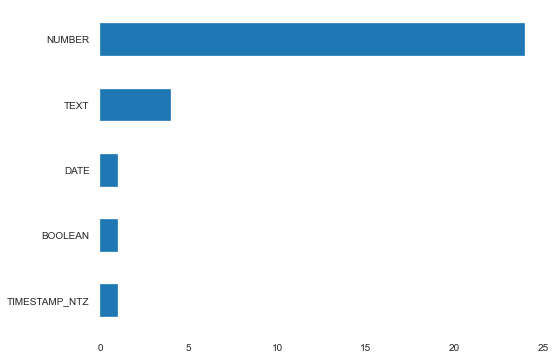

In [30]:
data_types = df_cols['DATA_TYPE'].value_counts()

print(data_types)
plt.figure(figsize=(8,6))
data_types.sort_values(inplace=True)
data_types.plot.barh()


In [42]:
for index, row in df_infoschema.iterrows():
    
    table = row['TABLE_NAME']
    print(table)
    
    tmp_html = ''
    tmp_html += '<!DOCTYPE html><html><head>'
    tmp_html += '<link rel="stylesheet" href="https://unpkg.com/purecss@2.0.3/build/pure-min.css" integrity="sha384-cg6SkqEOCV1NbJoCu11+bm0NvBRc8IYLRGXkmNrqUBfTjmMYwNKPWBTIKyw9mHNJ" crossorigin="anonymous">'
    tmp_html += '<meta name="viewport" content="width=device-width, initial-scale=1">'
    tmp_html += '</head>'
    tmp_html += '<body style="font-family:sans-serif;padding-left:20px;padding-right:20px;background-color:white">'
    tmp_html += '<h2>' + table + '</h2>'
    
    if row['COMMENT'] is not None:
        tmp_html += '<p><b>COMMENT: </b>' + row['COMMENT'] + '</p>'
        
    tmp_html += '<p><b>CREATED: </b>' + str(row['CREATED']) + '</p>'
    tmp_html += '<p><b>LAST_ALTERED: </b>' + str(row['LAST_ALTERED']) + '</p>'
    
    
    row_count = row['ROW_COUNT']
    row_count = "{:,}".format(row_count)
    tmp_html += '<p><b>ROWS: </b>' + str(row_count) + '</p>'
    
    df_cols = df_info_cols[df_info_cols['TABLE_NAME'] == table]
    tmp_html += '<p><b>COLUMNS: </b>' +  str(df_cols.shape[0])
    
    table_bytes = row['BYTES']
    table_bytes = "{:,}".format(table_bytes)
    tmp_html += '<p><b>BYTES: </b>' + str(table_bytes) + '</p>'

    tmp_html += '<p><b>COLUMN DATA TYPES:</b></p>'
    data_types = df_cols['DATA_TYPE'].value_counts()
    df_dtypes = data_types.to_frame()
    df_dtypes.sort_values(by = ['DATA_TYPE'], ascending=False)
    tmp_html += df_dtypes.to_html()

    tmp_html += '<br><br>'
    tmp_html += '<hr>'
    
    # Finish the HTML
    tmp_html += '</body></html>'
    
    # Write HTML to file
    # 
    f = open( "content/overview_" + table + ".html", "w+")
    f.write(tmp_html)
    f.close()
    
    

CT_US_COVID_TESTS
DATABANK_DEMOGRAPHICS
DEMOGRAPHICS
GOOG_GLOBAL_MOBILITY_REPORT
HDX_ACAPS
HS_BULK_DATA
HUM_RESTRICTIONS_AIRLINE
HUM_RESTRICTIONS_COUNTRY
IHME_COVID_19
JHU_COVID_19
JHU_DASHBOARD_COVID_19_GLOBAL
KFF_HCP_CAPACITY
KFF_US_ICU_BEDS
KFF_US_POLICY_ACTIONS
KFF_US_STATE_MITIGATIONS
METADATA
NYC_HEALTH_TESTS
NYT_US_COVID19
NYT_US_REOPEN_STATUS
PCM_DPS_COVID19
PCM_DPS_COVID19_DETAILS
RKI_GER_COVID19_DASHBOARD
SCS_BE_DETAILED_HOSPITALISATIONS
SCS_BE_DETAILED_MORTALITY
SCS_BE_DETAILED_PROVINCE_CASE_COUNTS
SCS_BE_DETAILED_TESTS
VH_CAN_DETAILED
WHO_SITUATION_REPORTS


# Generate Metadata

In [19]:
# Create an HTML metadata summary for each table

# Prevent truncating of strings from df
pd.set_option("display.max_colwidth", 10000) 

# Build HTML summary for each table
for table in lst_tablenames_meta:
    # print (table)
    tmp_html = ''
    tmp_html += '<!DOCTYPE html><html><head>'
    tmp_html += '<link rel="stylesheet" href="https://unpkg.com/purecss@2.0.3/build/pure-min.css" integrity="sha384-cg6SkqEOCV1NbJoCu11+bm0NvBRc8IYLRGXkmNrqUBfTjmMYwNKPWBTIKyw9mHNJ" crossorigin="anonymous">'
    tmp_html += '<meta name="viewport" content="width=device-width, initial-scale=1">'
    tmp_html += '</head>'
    tmp_html += '<body style="font-family:sans-serif;padding-left:20px;padding-right:20px;background-color:white">'
    tmp_html += '<h2>' + table + '</h2>'
    
    df_temp = df.loc[(df['TABLE'] == table) & (df['COLUMN'].isnull())]

    # Table description
    tmp_html += (df_temp['DESCRIPTION'].to_string(index=False)).lstrip()
    
    # Column metadata
    df_col = df.loc[(df['TABLE'] == table) & (df['COLUMN'].notnull())]
    df_col = df_col[['COLUMN', 'DESCRIPTION', 'COMMENTS', 'SOURCE']]
    df_col = pd.DataFrame(df_col, index=None)
    
    df_col.rename(columns = {'COLUMN':'COLUMN_NAME'}, inplace = True)
    tmp_html += df_col.to_html(justify='left', index=False, classes='pure-table pure-table-bordered')
    tmp_html += '<br><br>'
    tmp_html += '<hr>'
    
    # Finish the HTML
    tmp_html += '</body></html>'
    
    # Write HTML to file
    # 
    f = open( "content/metadata_" + table + ".html", "w+")
    f.write(tmp_html)
    f.close()

# Display to screen
# display(HTML(tmp_html))


# Generate Data Previews

In [21]:
# Create an HTML data preview for each table

# Prevent truncating of strings from df
pd.set_option("display.max_colwidth", 10000) 

# Build HTML summary for each table

for table in lst_tablenames_info:
    # print (table)
    tmp_html = ''
    tmp_html += '<!DOCTYPE html><html><head>'
    tmp_html += '<link rel="stylesheet" href="https://unpkg.com/purecss@2.0.3/build/pure-min.css" integrity="sha384-cg6SkqEOCV1NbJoCu11+bm0NvBRc8IYLRGXkmNrqUBfTjmMYwNKPWBTIKyw9mHNJ" crossorigin="anonymous">'
    tmp_html += '<meta name="viewport" content="width=device-width, initial-scale=1">'
    tmp_html += '</head>'
    tmp_html += '<body style="background-color:white;font-family:sans-serif;padding-left:20px;padding-right:20px">'
    tmp_html += '<h2>' + table + '</h2>'
    
    table_query = 'select * from "STARSCHEMA_COVID19"."PUBLIC"."' + table + '";'
    df_table = pd.read_sql(table_query, ctx)

    # First rows
    tmp_html += "<h3>First 5 Rows</h3>"
    df_temp = df_table.head(5)
    tmp_html += df_temp.to_html(classes='pure-table pure-table-bordered')

    # Random sample of rows
    tmp_html += "<h3>Random 10 Rows</h3>"
    df_temp = df_table.sample(n=10)
    tmp_html += df_temp.to_html(classes='pure-table pure-table-bordered')
    
    # Last rows
    tmp_html += "<h3>Last 5 Rows</h3>"
    df_temp = df_table.tail(5)
    tmp_html += df_temp.to_html(classes='pure-table pure-table-bordered')
    
    tmp_html += '<br><br>'
    tmp_html += '<hr>'
    
    # Finish the HTML
    tmp_html += '</body></html>'
    
    # Write HTML to file
    # 
    f = open( "content/data_preview_" + table + ".html", "w+")
    f.write(tmp_html)
    f.close()

# Generate Data Profiles

In [93]:
# This function generates the data profile report and saves it to an HTML file
def generate_data_profile(df_table, table_name):
    
    filename = 'data_profile_' + table_name + ".html"
    rpt_title = 'Data Profile: ' + table_name.upper()
    
    myreport = ProfileReport(df_table, title=rpt_title, minimal=True)
    # myreport = ProfileReport(df_table, title=rpt_title)

#     myreport = ProfileReport(df_table, title="Pandas Profiling Report",

#         missing_diagrams={
#             "bar": True,
#             "matrix": False,
#             "heatmap": False,
#             "dendrogram": False                    
#         },

#         correlations={
#             "pearson":{
#                 "calculate": True,
#                 "warn_high_correlations": True,
#                 "threshold": 0.9
#             } ,
#             "spearman":{
#                 "calculate": False,
#                 "warn_high_correlations": False},
#             "kendall":{
#                 "calculate": False,
#                 "warn_high_correlations": False},
#             "phi_k":{
#                 "calculate": False,
#                 "warn_high_correlations": False},
#             "cramers":{
#                 "calculate": False,
#                 "warn_high_correlations": True,
#                 "threshold": 0.9},
#             "recoded":{
#                 "calculate": False,
#                 "warn_high_correlations": True,
#                 "threshold": 1.0}
#         },

#         samples={
#             "head": 3,
#             "tail": 3 
#         }
#     )

    myreport.to_file(filename)

In [94]:
# Create a data profile for each table and save to HTML

# Get list of tables
qry_tablenames = 'show tables in schema "STARSCHEMA_COVID19"."PUBLIC";'
results = cs.execute(qry_tablenames).fetchall()

i = 0
print('GENERATING DATA PROFILES for TABLES')
print('--------------------------')
for r in results:
    
    # NOTE: Exclude HS_BULK_DATA because too sparse
    if r[1] != "HS_BULK_DATA":
        if i >= 30:
            exit()
        else:
            df = None
            sf_table = r[1]
            # NOTE:  Use limit or sample to control how much to retrieve
            #table_query = 'select * from "COVID19"."PUBLIC"."' + sf_table + '" + ' limit 10,000;'
            table_query = 'select * from "STARSCHEMA_COVID19"."PUBLIC"."' + sf_table + '" sample (100 rows);'


            df = pd.read_sql(table_query, ctx)
            # print(df.head(3))

            print(r[1] + ' ' + str(df.shape))

            generate_data_profile(df, sf_table)
        
            i += 1

print('--------------------------')
print('Total Table Profiles: ' + str(len(results)))

GENERATING DATA PROFILES for TABLES
--------------------------
CT_US_COVID_TESTS (100, 31)



DATABANK_DEMOGRAPHICS (100, 11)



DEMOGRAPHICS (100, 10)



GOOG_GLOBAL_MOBILITY_REPORT (100, 14)



HDX_ACAPS (100, 15)


...


SCS_BE_DETAILED_PROVINCE_CASE_COUNTS (100, 11)



SCS_BE_DETAILED_TESTS (100, 3)



VH_CAN_DETAILED (100, 9)



WHO_SITUATION_REPORTS (100, 14)



--------------------------
Total Table Profiles: 27
